In [1]:
import pathlib
import json
import re
import os

from IPython.display import display
import matplotlib.pyplot
import numpy
import polars
from tqdm.notebook import tqdm

EVALUATION_DIR = pathlib.Path.cwd() / "06_1evaluation"
os.environ["EVALUATION_DIR"] = str(EVALUATION_DIR)

Chrome Version (2026-04-22): 147.0.7727.101

In [2]:
fcps = []
jsons = list((EVALUATION_DIR / "output-dataset").glob("lighthouse-run-*.report.json"))

for json_report in tqdm(jsons):
    with open(json_report) as json_file:
        obj = json.load(json_file)
        try:
            fcp = obj["audits"]["first-contentful-paint"]["numericValue"]
            error = None
        except KeyError:
            fcp = None
            error = obj["runtimeError"]["code"]

            if error == "ERRORED_DOCUMENT_REQUEST":
                match = re.search(r"Status code: (\d+)", obj["runtimeError"]["message"])
                error = f"{error} (Status: {match[1]})"
        if not error:
            lcp = obj["audits"]["largest-contentful-paint"].get("numericValue")
            speed_index = obj["audits"]["speed-index"].get("numericValue")
            total_blocking_time = obj["audits"]["total-blocking-time"].get("numericValue")
            cumulative_layout_shift = obj["audits"]["cumulative-layout-shift"].get("numericValue")
        else:
            lcp = None
            speed_index = None
            total_blocking_time = None
            cumulative_layout_shift = None
        match = re.match(r"lighthouse-run-(?P<domain>.*)-(?P<run>\d{3})-(?P<compress>true|false)-(?P<packed>true|false)-(?P<lhts>\d+)(?P<extra>.*)?\.report\.json", json_report.name)
        
        res = match.groupdict()
        res["run"] = int(res["run"])
        res["compress"] = res["compress"] == "true"
        res["packed"] = res["packed"] == "true"
        res["lhts"] = int(res["lhts"])
        res["extra"] = res["extra"].strip("-_")
        res["fcp"] = fcp
        res["lcp"] = lcp
        res["speed_index"] = speed_index
        res["total_blocking_time"] = total_blocking_time
        res["cumulative_layout_shift"] = cumulative_layout_shift
        res["error"] = error
        res["filename"] = json_report.name
        fcps.append(res)

df = polars.DataFrame(fcps).rename(
    {
        "lhts": "lighthouse_timestamp",
        "fcp": "first_contentful_paint",
        "lcp": "largest_contentful_paint",
    }
)
df.write_parquet(EVALUATION_DIR / "output-dataset" / "lighthouse.parquet")

  0%|          | 0/400 [00:00<?, ?it/s]

Metric,min.,max.,mean,std
str,f64,f64,f64,f64
"""first_contentful_paint""",-5001.2805,6636.782,158.996629,1133.091141
"""largest_contentful_paint""",-9936.0786,23888.06,691.434515,3696.657267
"""speed_index""",-7114.388888,9996.739038,488.63896,2574.747532
"""total_blocking_time""",-916.5,4831.8467,36.656173,459.00915


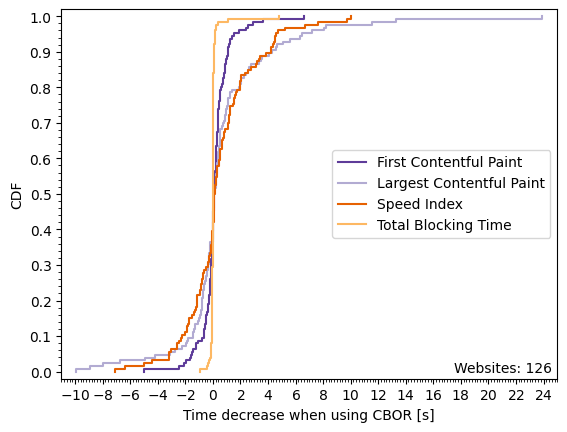

In [3]:
df = polars.read_parquet(EVALUATION_DIR / "output-dataset" / "lighthouse.parquet")

ax = matplotlib.pyplot.gca()
stats = None

METRIC_COLORS = {
    "first_contentful_paint": "#5e3c99",
    "largest_contentful_paint": "#b2abd2",
    "speed_index": "#e66101",
    "total_blocking_time": "#fdb863",
}

for metric in ["first_contentful_paint", "largest_contentful_paint", "speed_index", "total_blocking_time"]:
    times = df.filter(~polars.col("packed")).select(
        ["compress", "domain", "run", metric]
    ).pivot(
        "compress",
        index=["domain", "run"],
        values=[metric]
    ).filter(
        polars.col("true").is_not_null()
        & polars.col("false").is_not_null()
    ).rename(
        {
            "true": "Compressed",
            "false": "Not compressed",
        }
    ).with_columns(
        Difference=polars.col("Not compressed") - polars.col("Compressed")
    )
    #display(times)
    domains = times.select(polars.col("domain").unique()).shape[0]
    # audits = times.shape[0]
    #matplotlib.pyplot.clf()

    comp = "Difference"
    ax.ecdf(times[comp], label=metric.replace("_", " ").title(), color=METRIC_COLORS[metric])
    stat = polars.DataFrame(
        [
            {
                "Metric": metric,
                "min.": times[comp].min(),
                "max.": times[comp].max(),
                "mean": times[comp].mean(),
                "std": times[comp].std(),
            }
        ]
    )
    if stats is None:
        stats = stat
    else:
        stats = polars.concat([stats, stat])
display(stats)
ax.set_xlabel(f"Time decrease when using CBOR [s]")
ax.set_xlim(-11000, 25000)
ax.set_xticks(numpy.arange(-10000, 25100, 2000))
ax.set_xticks(numpy.arange(-11000, 25100, 200), minor=True)
ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x / 1000.0:.0f}$"))
ax.set_ylabel("CDF")
ax.set_ylim(-0.02, 1.02)
ax.set_yticks(numpy.arange(0, 1.1, 0.1))
ax.set_yticks(numpy.arange(0, 1.02, 0.02), minor=True)
ax.text(
    0.99,
    0.01,
    f"Websites: {domains}", # (successful audits / site: {audits / domains:.2f} / 3.00)", 
    ha="right",
    va="bottom",
    transform=ax.transAxes,
)
ax.legend()
matplotlib.pyplot.show()

domain,error
str,str
"""gtld-servers.net""","""CHROME_INTERSTITIAL_ERROR"""
"""gstatic.com""","""ERRORED_DOCUMENT_REQUEST (Status: 404)"""
"""googleapis.com""","""ERRORED_DOCUMENT_REQUEST (Status: 404)"""
"""pv-cdn.net""","""CHROME_INTERSTITIAL_ERROR"""
"""akamai.net""","""CHROME_INTERSTITIAL_ERROR"""
…,…
"""ilikedoctor.com""","""ERRORED_DOCUMENT_REQUEST (Status: 502)"""
"""ad-account-buy.top""","""CHROME_INTERSTITIAL_ERROR"""
"""sportzonline.click""","""NOT_HTML"""


error,len
str,u64
"""ERRORED_DOCUMENT_REQUEST (Status: 400)""",2
"""NO_FCP""",24
"""ERRORED_DOCUMENT_REQUEST (Status: 404)""",10
"""NOT_HTML""",2
"""ERRORED_DOCUMENT_REQUEST (Status: 451)""",2
"""ERRORED_DOCUMENT_REQUEST (Status: 502)""",30
"""ERRORED_DOCUMENT_REQUEST (Status: 403)""",6
"""CHROME_INTERSTITIAL_ERROR""",71


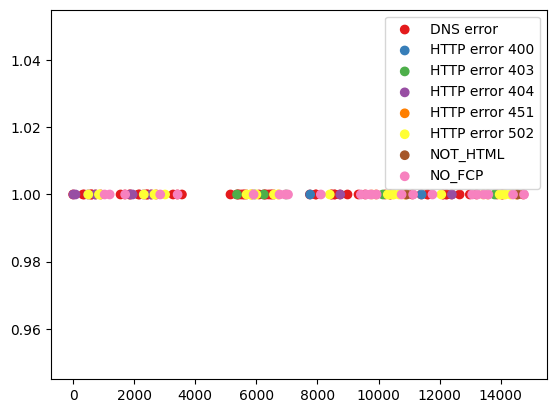

In [4]:
with polars.Config(fmt_str_lengths=df["error"].str.len_chars().max()):
    display(df.filter(polars.col("error").is_not_null()).select(["domain", "error"]))
    display(df.filter(polars.col("error").is_not_null()).group_by("error").len())

stat = df.filter(polars.col("error").is_not_null()).with_columns(
    polars.col("error").str.replace(
        r"ERRORED_DOCUMENT_REQUEST \(Status: (\d+)\)", "HTTP error ${1}"
    ).str.replace(
        r"CHROME_INTERSTITIAL_ERROR", "DNS error",
    ),
    polars.col("lighthouse_timestamp") - polars.col("lighthouse_timestamp").min(),
)
categories = stat["error"].unique().sort().to_list()
colors = dict(zip(categories, matplotlib.colormaps['Set1'].colors))
stat = stat.with_columns(
    color=polars.col("error").replace_strict(colors),
)

for category in categories:
    ds = stat.filter(polars.col("error") == category)
    matplotlib.pyplot.scatter(ds["lighthouse_timestamp"], ds["run"], c=ds["color"], label=category)
matplotlib.pyplot.legend()

In [5]:
df.filter(polars.col("error") == "NO_FCP")

domain,run,compress,packed,lighthouse_timestamp,extra,first_contentful_paint,largest_contentful_paint,speed_index,total_blocking_time,cumulative_layout_shift,error,filename
str,i64,bool,bool,i64,str,f64,f64,f64,f64,f64,str,str
"""dry.hu""",1,true,false,1776861860,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-dry.hu-001-true…"
"""airbaud.net""",1,true,false,1776862024,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-airbaud.net-001…"
"""c2x.com.br""",1,true,false,1776862531,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-c2x.com.br-001-…"
"""dry.hu""",1,false,false,1776863679,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-dry.hu-001-fals…"
"""c2x.com.br""",1,false,false,1776864249,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-c2x.com.br-001-…"
…,…,…,…,…,…,…,…,…,…,…,…,…
"""gruma.com.au""",1,false,false,1776874063,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-gruma.com.au-00…"
"""xlgs.net""",1,false,false,1776874268,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-xlgs.net-001-fa…"
"""universalsports.com""",1,false,false,1776874423,"""us-west""",null,null,null,null,null,"""NO_FCP""","""lighthouse-run-universalsports…"


In [6]:
lf = df.select("domain").unique("domain").lazy().join(
    polars.scan_csv(EVALUATION_DIR / "tranco_3QL4L.csv", has_header=False, new_columns=["rank", "domain"]),
    on="domain",
).sort("rank")
res = lf.collect()
with polars.Config(tbl_rows=df.shape[0]):
    display(lf.collect())

domain,rank
str,i64
"""google.com""",1
"""gtld-servers.net""",2
"""gstatic.com""",3
"""facebook.com""",4
"""cloudflare.com""",5
"""googleapis.com""",6
"""microsoft.com""",7
"""mail.ru""",8
"""youtube.com""",9
